In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##Task-1 Data Loading & Exploration
Load the CSV file using Pandas

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/HousePricePrediction_Joshi_Aarati/Housing.csv')

Display the first 10 rows

In [4]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Check how many rows and columns are there

In [5]:
print("Size of Dataset:", df.shape)
print("Rows:", df.shape[0])   #first 0 index tells about total rows
print("Columns:", df.shape[1])  #and the second 1 index tells about total colums

Size of Dataset: (545, 13)
Rows: 545
Columns: 13


Identify which column is the target (Price) and which are features

In [6]:
print(df.columns) #amoung all features price is at 0th index

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


Check for missing values in each column

In [8]:
df.isnull().sum() #here any cell don't contain null value

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


##Task-2 Data Cleaning
Handle missing values (fill or drop, whichever fits the column)

In [9]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())
df.dropna(inplace=True)
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())   #there no any null value as describe early

Missing Values Before Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Missing Values After Cleaning:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


Remove duplicate rows, if any

In [10]:
print("Duplicate Rows Before:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("Duplicate Rows After:", df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After: 0


Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [12]:
categorical_columns = df.select_dtypes(include=['object']).columns
print("Categorical columns:")
print(categorical_columns) #this given columns contain categorical data

Categorical columns:
Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')


In [13]:
df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)
print("Dataset after encoding:", df.shape)

Dataset after encoding: (545, 14)


In [14]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [15]:
df.info() #all categorical value replace with bool(T,F) values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   parking                          545 non-null    int64
 6   mainroad_yes                     545 non-null    int64
 7   guestroom_yes                    545 non-null    int64
 8   basement_yes                     545 non-null    int64
 9   hotwaterheating_yes              545 non-null    int64
 10  airconditioning_yes              545 non-null    int64
 11  prefarea_yes                     545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    i

Keep only the columns that are meaningful for predicting price

In [16]:
X = df.drop('price', axis=1)
y = df['price']
print("Feature Shape:", X.shape) # X is features
print("Target Shape:", y.shape)  # y is price column only

Feature Shape: (545, 13)
Target Shape: (545,)


##Task-3 Model Building
Split the data into training and test sets (80/20)

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (436, 13)
Testing Features Shape: (109, 13)
Training Target Shape: (436,)
Testing Target Shape: (109,)


Train a Linear Regression model to predict house price

In [18]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


Evaluate it using MAE, RMSE, and R² Score

In [19]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

lr_pred = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R² Score:", lr_r2)

Linear Regression Results
-------------------------
MAE : 970043.4039201636
RMSE: 1324506.9600914386
R² Score: 0.6529242642153184


Train a second model — Random Forest Regressor

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100,random_state=42)
rf_model.fit(X_train, y_train)
print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


In [21]:
rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R² Score:", rf_r2)

Random Forest Results
---------------------
MAE : 1021546.0353211008
RMSE: 1400565.9728553821
R² Score: 0.611918531405699


Compare Model Performance

In [22]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2 Score': [lr_r2, rf_r2]
})

comparison # Lower MAE and RMSE is Better , Higher R² Score is Better

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


In [28]:
# give more clear understanding
print("Linear Regression Accuracy:", round(lr_r2 * 100, 2), "%")
print("Random Forest Accuracy:", round(rf_r2 * 100, 2), "%")

Linear Regression Accuracy: 65.29 %
Random Forest Accuracy: 61.19 %


## Task-4 Visualization (Minimum 3 charts)
Chart 1: Histogram Showing Distribution of House Prices

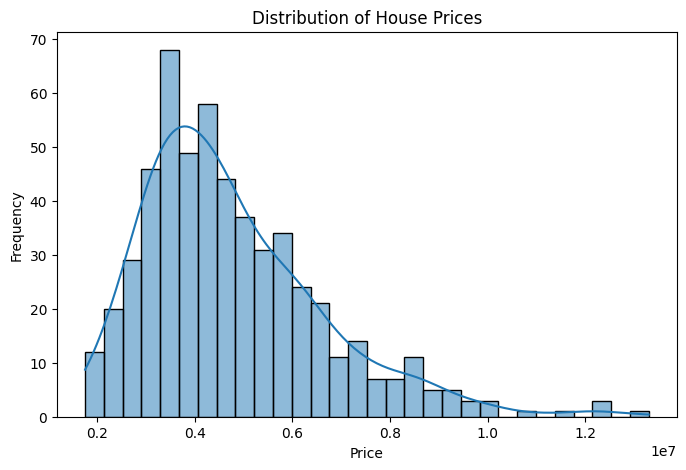

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/HousePricePrediction_Joshi_Aarati/chart1_house_price_distribution.png')
plt.show()

Chart 2: Correlation heatmap showing which features relate most strongly to price

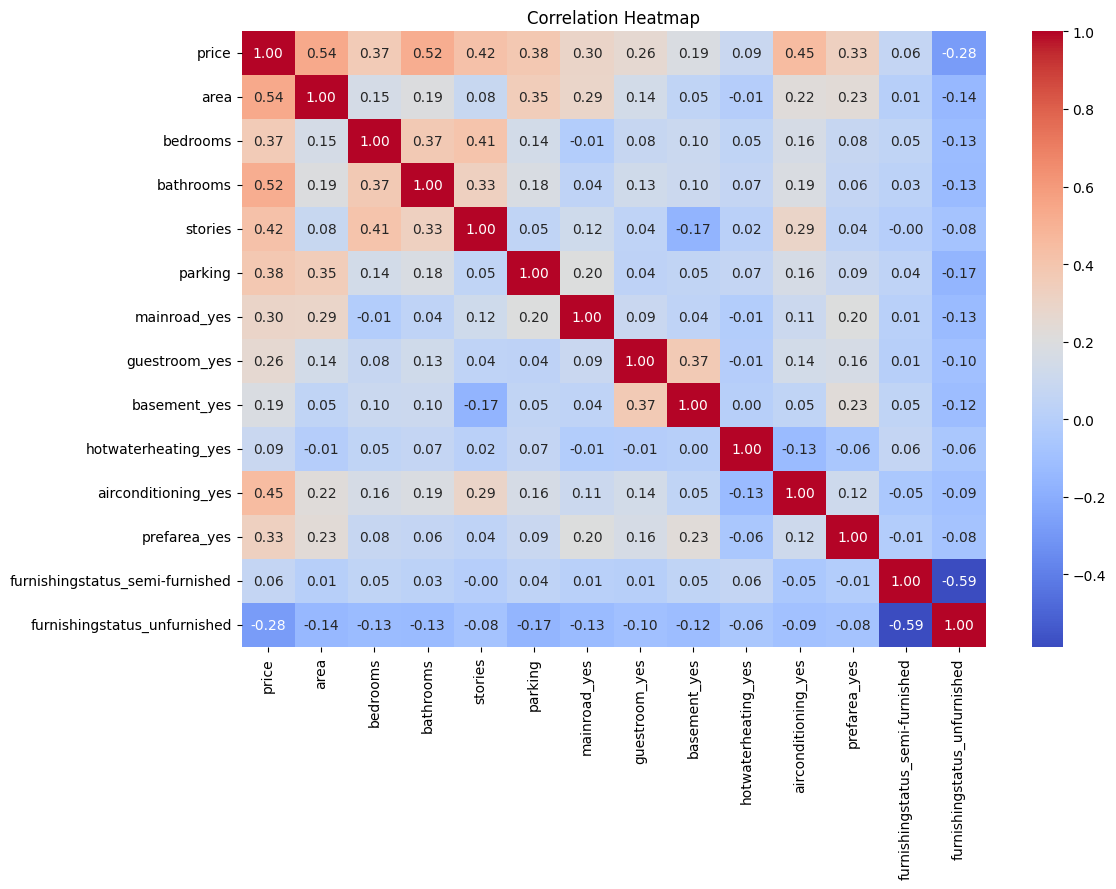

In [25]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/HousePricePrediction_Joshi_Aarati/chart2_correlation_heatmap.png')
plt.show()

Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter
plot, price vs. area scatter plot, etc.)

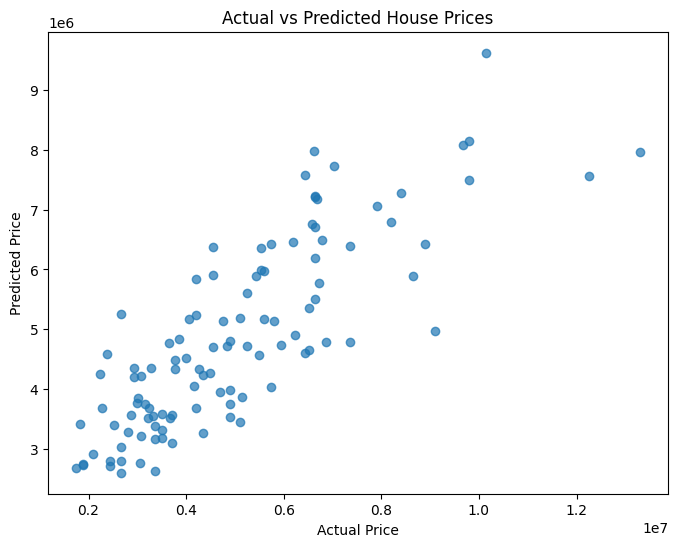

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,lr_pred,alpha=0.7)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted House Prices')
plt.savefig('/content/drive/MyDrive/Colab Notebooks/XYlnfy AI Internship/HousePricePrediction_Joshi_Aarati/chart3_actual_vs_predicted.png')
plt.show()

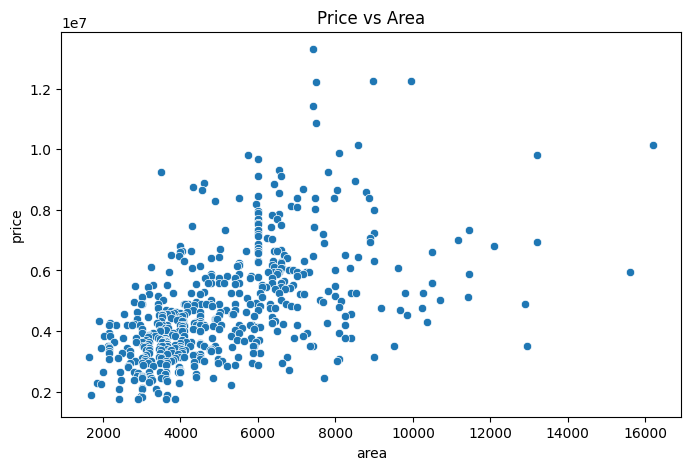

In [27]:
# Additional
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['area'],
    y=df['price']
)

plt.title('Price vs Area')

plt.show()

##Summery
The analysis showed that area, number of bathrooms, number of stories, and air conditioning were among the most influential features affecting house prices. The Linear Regression model achieved an R^2 score of approximately 65%, which means it was able to explain a significant portion of the variation in house prices. Although the model was reasonably accurate, there is still room for improvement by including additional features such as location and neighborhood information. One surprising finding was that Linear Regression performed slightly better than Random Forest on this dataset. The results also showed a strong positive relationship between house area and price. Based on these findings, real estate businesses should focus on property size and key amenities when estimating house values and making pricing decisions.
